<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#0400ffff'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
    - [4.1 Define new index](#4_1)
- [5. Data Preprocessing](#5)
    - [5.1 Types Correction](#5_1)
        - [5.1.1 Year and previousOwners columns correction](#5_1_1)
        - [5.1.2 hasDamage Column Correction](#5_1_2)
    - [5.2 Categorical Features correction](#5_2)
        - [5.2.1 Correct the values](#5_2_1)
        - [5.2.2 Check corrections](#5_2_2)
    - [5.3 Invalid Values](#5_3)
        - [5.3.1 Invalid Values Analysis](#5_3_1)
        - [5.3.2 Invalid Values Treatment](#5_3_2)
- [6. Data Partition](#6)
- [7. Data Transformation](#7)
    - [7.1 Outliers Treatment](#7_1)
    - [7.2 Feature Engineering ](#7_2)
    - [7.3 Missing Values Imputation](#7_3)
    - [7.4 Scaling Features](#7_4)
    - [7.5 Save the Processed Data](#7_5)
    - [7.6 Encoding](#7_6)
- [8. Feature Selection](#8)
    - [8.1 Remove paintQuality%](#8_1)
    - [8.2 Filter Methods](#8_2)
        - [8.2.1 Removing Constant Features](#8_2_1)
        - [8.2.2 Correlation between features - Redundant Features](#8_2_2)
        - [8.2.3 Correlation with the target - Relevant Features](#8_2_3)
    - [8.3 Wrapped Methods](#8_3)
        - [8.3.1 RFE](#8_3_1)
    - [8.4 Embedded Methods](#8_4)
        - [8.4.1 Lasso](#8_4_1)
    - [8.5 Comparison between Models](#8_5)
- [9. Model and Assessment](#9)
    - [9.1 Create a Sample to Test Models](#9_1)
    - [9.2 Define the Scores to Evaluate](#9_2)
    - [9.3 KNN](#9_3)
        - [9.3.1 Define Model and Grid Parameters](#9_3_1)
        - [9.3.2 Test KNN using Samples](#9_3_2)
        - [9.3.3 Test KNN using the entire Dataset](#9_3_3)
- [10. Save results to Kaggle](#10)
- [11. End of the Notebook](#11)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#TOP)
</a>

!!!colocar o abstract final depois 

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#TOP)
</a>

The development of the analyses and models for this project relies on a robust set of Python libraries. Pandas and NumPy are utilized for efficient data manipulation, cleaning, and numerical operations, while Matplotlib and Seaborn support the creation of clear and informative visualizations. Auxiliary libraries such as os, math, and difflib facilitate file management, mathematical calculations, and the correction of categorical variables via text similarity, respectively.

Data preprocessing is executed using Scikit-learn, employing tools like OneHotEncoder for encoding, and a combination of MinMaxScaler, StandardScaler, and RobustScaler for normalization, ensuring resilience against outliers. Missing value handling is managed through simple and nearest-neighbor (KNNImputer) imputation strategies.

Feature selection is addressed comprehensively through three methodologies: filter methods (including VarianceThreshold, Spearman correlation, SelectKBest, and Mutual Information), wrapper methods (RFE - Recursive Feature Elimination), and embedded methods (Lasso).

For predictive modeling, the project explores various regression algorithms, including K-Nearest Neighbors (KNN), Random Forest, and Neural Networks (MLPRegressor), with hyperparameter optimization conducted via RandomizedSearchCV. Rigorous performance evaluation is ensured by metrics such as R^2, MAE, MSE, and MAPE, complemented by detailed statistical analysis provided by Statsmodels. Finally, result reproducibility is guaranteed through the definition of random seeds.


In [1]:
# General Useful Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math

# Text Similarity - Categorical Features Correction
from difflib import SequenceMatcher

# Scaling and Encoding
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, MinMaxScaler, StandardScaler, RobustScaler

# Missing Value Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Data Partition
from sklearn.model_selection import train_test_split

#filter methods
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr

# spearman 
from sklearn.feature_selection import SelectKBest, f_regression

# mutual information
from sklearn.feature_selection import mutual_info_classif

#wrapper methods
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

# embedded methods
from sklearn.linear_model import Lasso

from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

#KNN
from sklearn.neighbors import KNeighborsRegressor

# Random Forest
from sklearn.ensemble import RandomForestRegressor

#Neural Network
from sklearn.neural_network import MLPRegressor

# DecisionTree
from sklearn.tree import DecisionTreeRegressor

# Random Forest
from sklearn.ensemble import RandomForestRegressor

# Bagging
from sklearn.ensemble import BaggingRegressor

#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
import sys
sys.path.append("../")

from Source.visualizations import *
from Source.data_preprocessing import *
from Source.feature_engineering import *
from Source.feature_selection import *
from Source.model_and_assessment import *

# Set random seed for reproducibility
np.random.seed(40111)


#!pip install tqdm tqdm-joblib

from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#TOP)
</a>

Understanding the features is essential to interpret the data correctly and conduct the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An attribute that contains an identifier for each car.

**Brand:** The car's main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**fuelType:** The type of fuel used by the car (Diesel, Petrol, Hybrid, Electric).

**mpg:** The car's consumption of fuel expressed in average miles per gallon.

**engineSize:** Size of the engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.

<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#TOP)
</a>

Here, we are importing with pd.read_csv() the files to start our project and converting them into Pandas DataFrames. CarID was set to index since it's the unique identifier in all data sets.

In [2]:
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

AttributeError: 'function' object has no attribute 'read_csv'

<a class="anchor" id="4">

## **4.1** Define new index

[Back to TOP](#TOP)
</a>

For all partitions we will assign the "carID" column as the index, as it represents the number identifier for each individual car.

In [ ]:
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Data Cleaning**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_1">

## **5.1** Metric Features Correction
[Back to TOP](#TOP)
</a>

During the Exploratory Data Analysis (EDA) we identified some erros that will now be treated:

- In the columns `Year`, `hasDamage` and `previousOwners` floats exist but these columns should only have integers as they represent discrete variables and a boolean in the case of hasDamage.

- In some columns negative values exist that make no sense.

- The column hasDamage is binary but only has 0's and Nan, what lead us to think that the Nan values represent the 1's.

For these mistakes we will:

- Consider the integer part to the floats that should be integers.

- Replace the negative values with Nan to later be treated has missing values.

- Fill the Nan values with 1's in the hasDamage feature.

Regarding the negative tax values, we thought they could represent to incentives on electric vehicles, so we will see if this checks out.

In [ ]:
negtax_electric = train[(train['tax'] < 0) & (train['fuelType'] == 'Electric')]
print(f"Number of rows with negative 'tax' and 'Electric' fuel type: {len(negtax_electric)}")
negtax_electric[['tax', 'fuelType']].head(10)

Number of rows with negative 'tax' and 'Electric' fuel type: 0


,tax,fuelType
carID,,


From this analysis, we see that there are no electric vehicles with negative tax, so we eliminate that possibility and correct all negative values by using a function defined by us on the `data_preprocessing.py` file.

In [ ]:
train = correct_metric_features(train)
test = correct_metric_features(test)

<a class="anchor" id="5_2">

## **5.2** Categorical Features Correction

[Back to TOP](#TOP)

We had identified earlier that the categorical features present a lot of misspellings. We will address that here using a function specifically created to correct these values.

<a class="anchor" id="5_2_1">

### **5.2.1** Correct the values

[Back to TOP](#TOP)

Now we are able to correct the values by calling the function.

To reach the thresholds for each feature, we used a trial and error approach. We found that the optimal thresholds depend both on the length of the word and on the number and similarity between unique observations of each feature. 

To address these challenges, we created two thresholds, one for shorter words (<=5 characters) and another for longer words (>5 characters). This was important because the word similarity function we used (SequenceMatcher) uses ratios to identify similar words and so each character has different 'weights' based on the length of the word.

Because of the reduced number of unique observations on most features, we saw that this solution was particularly important for the "model" feature since it has a very high number of unique observations and also very similar model names.

In [ ]:
# Correct 'Brand' column
train = clean_with_diff(train, 'Brand', threshold_short=0.6, threshold_long=0.6)
test = clean_with_diff(test, 'Brand', threshold_short=0.6, threshold_long=0.6)

# Correct 'transmission' column
train = clean_with_diff(train, 'transmission', threshold_short=0.7, threshold_long=0.7)
test = clean_with_diff(test, 'transmission', threshold_short=0.7, threshold_long=0.7)

# Correct 'model' column
train = clean_with_diff(train, 'model', threshold_short=0.70, threshold_long=0.90)
test = clean_with_diff(test, 'model', threshold_short=0.70, threshold_long=0.90)

# Correct 'fuelType' column
train = clean_with_diff(train, 'fuelType', threshold_short=0.8, threshold_long=0.8)
test = clean_with_diff(test, 'fuelType', threshold_short=0.8, threshold_long=0.8)

<a class="anchor" id="5_2_2">

### **5.2.2** Check corrections

[Back to TOP](#TOP)

Now we will analyse the results of our treatments for each feature.

In [ ]:
corrected_columns = ['Brand', 'transmission', 'model', 'fuelType']

for column in corrected_columns:
    unique_values_train = train[column].unique()
    print(f"Unique values on the column '{column}' (train): {unique_values_train}")
    print('')
    print('-----------------------------------')
    print('')

Unique values on the column 'Brand' (train): ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'Hyundai' nan]

-----------------------------------

Unique values on the column 'transmission' (train): ['Semi-Auto' 'Manual' 'Automatic' nan 'unknown' 'Other']

-----------------------------------

Unique values on the column 'model' (train): [' Golf' ' Yaris' ' Q2' ' Fiesta' ' 2 Series' ' 3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Class' ' Q3' ' Fabia' ' Ka+'
 ' GLC Class' ' I10' ' C Class' ' Polo' ' E Class' ' Q5' ' Up' ' C-HR'
 ' Mokka X' ' Corsa' ' Astra' ' TT' ' 5 Series' ' Aygo' ' 4 Series' ' SLK'
 ' Viva' ' T-Roc' ' EcoSport' ' Tucson' nan ' X-CLASS' ' X2' ' Rapid'
 ' A1' ' Auris' ' Sharan' ' Adam' ' X3' ' A8' ' B-MAX' ' A4' ' Kona'
 ' Mokka' ' S-MAX' ' Crossland X' ' Tiguan' ' A5' ' Zafira' ' Ioniq' ' A6'
 ' Mondeo' ' Yeti Outdoor' ' X1' ' Scala' ' SL CLASS' ' 1 Series' ' Kamiq'
 ' Kuga' ' Tourneo Connect' ' Q7' ' Arteon' ' Santa Fe' ' Grandland X'
 ' 

**Important Note:** For most of the columns that were corrected, the function seems to have worked properly. However, in the case of the 'model' column, the results were not as good as in the other columns. This is because the original data contained a high number of unique and incorrect values, some of which were very similar to each other, having just one character difference between the wrong and correct model, but also just one different character from another model's name. This makes it impossible to achieve a perfect correction with this approach.

Example: 2 Serie (wrong), 3 Serie (wrong), 2 Series (correct), 3 Series (correct)

Nevertheless, the vast majority of the data is now properly cleaned and corrected and we will stick with this method.

Also based on the previous unique values analysis, we decided to check the percentage of the 'Other' category in the 'transmission' column. If the proportion is not significant, we believe it would be reasonable to replace it with an 'Unknown' category, as this simplification could make the next steps of our analysis easier and more consistent.

In [ ]:
(train[train['transmission'] == 'Other'].shape[0] / train.shape[0] * 100).__round__(4)

0.0066

The percentage is very small so we are going to replace the category as mentioned before.

In [ ]:
train = replace_category_transmission(train)
test = replace_category_transmission(test)

**Important:** Before applying any outliers treatment we need to split the data into train and validation sets. This is important to avoid data leakage. After splitting the data we can apply the method using only the training set statistics.

<a class="anchor" id="6">

# **6. Data Partition**

[Back to TOP](#TOP)

Define the independent features as X and the dependent as Y

In [ ]:
X = train.drop('price', axis = 1)
y = train['price']

Split the dataset into train and validation

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size = 0.2, random_state = 0,  shuffle = True)

<a class="anchor" id="7">

# **7. Data Transformation**

[Back to TOP](#TOP)

<a class="anchor" id="7_1">

## **7.1** Outliers Treatment

[Back to TOP](#TOP)

To identify outliers, we decided to use the **Interquartile Range (IQR) method** and apply it to all numerical features.

The following analysis identifies the number and percentage of outliers per features, helping to evaluate whether data cleaning or transformation is be necessary before modeling.

Here we will create a function to return a summary of the total number of outliers per feature and how much they represent of the total in percentage. This summary is based on the IQR method and we will analyse the train dataset only.

In [ ]:
outlier_summary(X_train)

,Column,Total Outliers,Percentage (%)
0,year,1437,2.36
1,mileage,2603,4.28
2,tax,15938,26.22
3,mpg,922,1.52
4,engineSize,494,0.81
5,paintQuality%,0,0.00
6,previousOwners,0,0.00
7,hasDamage,1257,2.07


From this, we take that most numeric features do not have a big share of outliers, as they represent less than 5% of all observations. Only the feature `tax` has a very big number of ouliers, with 26.23% of the whole population.

We are now going to analyse these graphically through boxplots.

KeyboardInterrupt: 

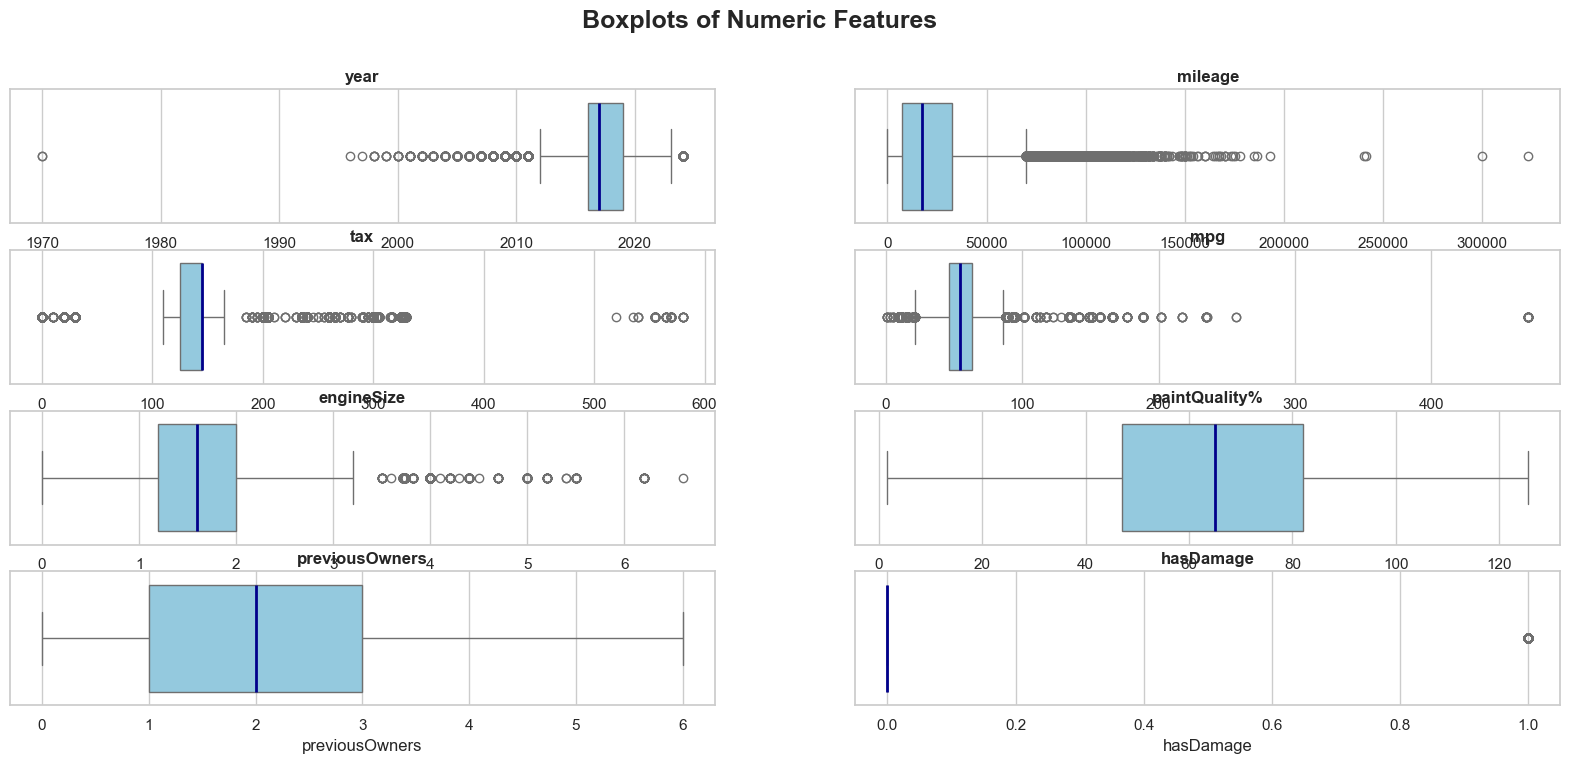

In [ ]:
create_boxplots(X_train)

We started by applying the IQR method and then we realized it eliminated too much data, which then hurt the model's results and decided to create different thresholds specific for each feature:

- `year:` between 1990 and 2020
- `mileage`,`tax`, `mpg`: 2.2 IQR multiplier
- `engineSize:` between 0.9L and 5.5L
- `previousOwners:` between 0 and 6

To reach the 2.2 IQR multiplier and the upper and lower limits, we used a trial and error approach. We found that 2.2 was a good middle ground because the default multiplier eliminated too many features and this is a way to widen the range of accepted results while eliminating extreme outliers.

Now specifically for each feature:

- `year:` Cars older than 1990 were extremely rare and introduced high price variance, while years beyond 2020 are not possible (dataset is from 2020); restricting the range improves data realism and model stability.
- `mileage:` Mileage has a strong right-skew; using a 2.2 IQR multiplier caps extreme values that disproportionately reduce accuracy without removing legitimate high-mileage cases.
- `tax:` Very high tax values occur infrequently and are often errors or special situations; applying a 2.2 IQR multiplier reduces the effect of unrealistic taxation outliers.
- `mpg:` Fuel efficiency extremes are uncommon and distort pricing; a 2.2 IQR multiplier tightens the distribution while preserving real variability across models.
- `engineSize:` Values below 0.9L or above 5.5L correspond to niche or erroneous entries; bounding engine size maintains realistic ranges and limits skew.
- `previousOwners:` The IQR visualisation shows no outliers for this feature and more than 6 previous owners is highly atypical. It signals noisy observations and capping reduces their undue influence on vehicle price.

Apply custom thresholds

In [ ]:
X_train_clean = treat_outliers_custom(X_train, X_train)
X_val_clean = treat_outliers_custom(X_train, X_val)
test_clean = treat_outliers_custom(X_train, test)

In [ ]:
X_train = X_train_clean.copy()
X_val = X_val_clean.copy()
test = test_clean.copy()

Visualize results after the outlier treatment

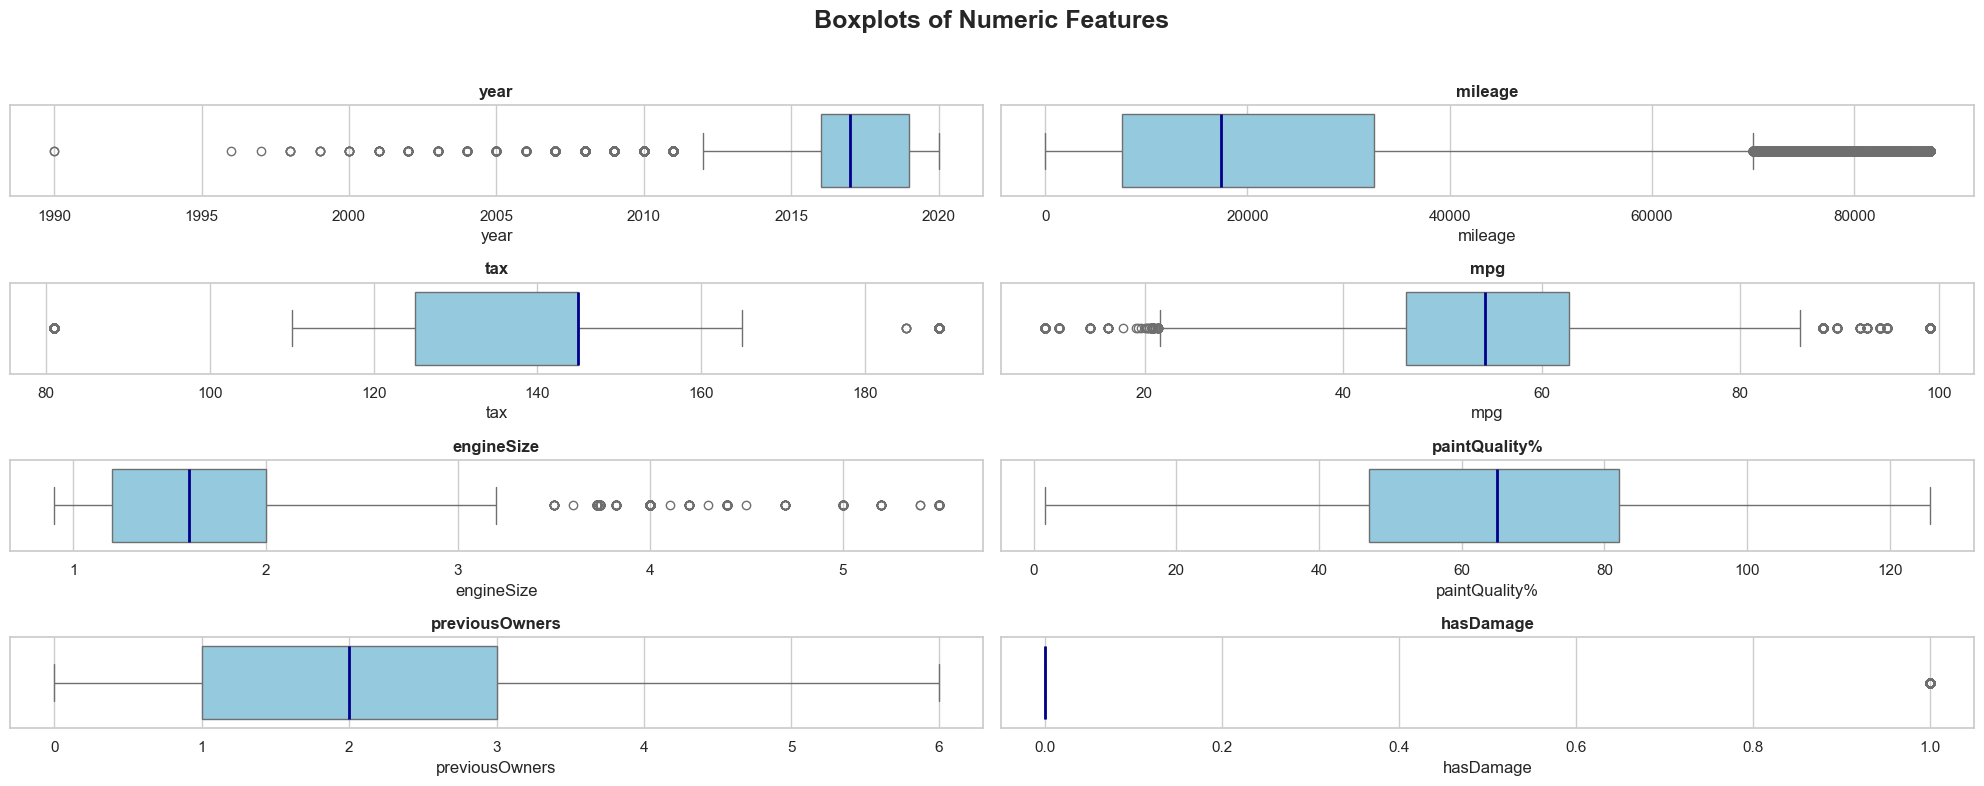

In [ ]:
create_boxplots(X_train)

Analysing our results, we see that the distributions are much more balanced, with fewer outliers. The outliers that remain should be significant for our analysis, as they are close to the IQR limits and have a significant number of observations.

<a class="anchor" id="7_2">

## **7.2** Feature Engineering

[Back to TOP](#TOP)

In this stage of the project, we created new features designed to enhance the predictive power of our model. These engineered variables fall into two main groups:

1. Features derived directly from existing variables, without using statistical aggregates such as mean, median or mode.
2. Features computed using aggregate statistics, which must be calculated exclusively on the training set (X_train) to avoid data leakage.

Below, we describe each feature and the motivation behind its inclusion.

**1. Directly Engineered Features**

- `car_age:` calculate the age of the car considering the current year and the year of its registration. This feature helps us to capture depreciation, this is, older cars tend to be cheaper.

- `is_recent_car:` binary flag, 1 if the car is less than 3 years old, otherwise 0. We decided to create this feature because highlights newer cars, usually have higher resale prices.

- `mileage_category:` transforms the original continuous mileage feature into an ordered categorical feature with five usage levels according to the total mileage.  This way it's easier to capture differences in vehicle wear and market value.

- `is_hybrid_or_eletric:` binary indicator that is 1 if the fuel type is Hybrid or Electric. Eco-friendly cars often hold higher market value.

- `is_automatic:`binary indicator that is 1 if the type of transmission is automatic or semi-automatic. Automatics typically cost more to buy and maintain.

- `fuel_eficciency_score:` Ratio of mpg / engineSize. Captures how efficiently the car converts fuel given engine capacity.

- `tax_to_engine_ratio:` Tax value divided by engine size. Indicates how expensive it is to maintain the car relative to its power.

- `tax_efficency:` mpg / tax. Measures how fuel-efficient the car is relative to its yearly tax burden.

- `is_first_owner:` binary indicator that is 1 if there were no previous owners. First-owner cars tend to have less wear, better care and higher prices.

- `ownership_ratio:` previousOwner / car_age. Captures how frequently ownership changed. Frequent changes might signal reliability issues.


**2. Features Based on Statistical Aggregation (Train-Only)**

- `brand_median_mileage:` median mileage per brand. Typical mileage level for each brand that is able to capture brand usage patterns.

- `brand_avg_engineSize`: engineSize mean per brand. Represents typical engine capacity of each brand.

- `model_median_tax:` median tax per model. Captures model-specific taxation tendencies.

- `fueltype_avg_mpg:` mpg mean per fuelType. Average fuel efficiency for each fuel type.

- `brand_avg_age:` car_age mean per brand. Average car age per brand, basically compare newer against older brands.

All feature engineering steps were encapsulated in a dedicated function, stored in the file feature_engineering.py, which was already imported and will be now applied to the dataset as needed.


In [ ]:
X_train.shape

(60778, 12)

In [ ]:
X_train_fe = create_features(X_train, X_train, current_year=2020, threshold=3)
X_val_fe = create_features(X_train, X_val, current_year=2020, threshold=3)
test_fe = create_features(X_train, test, current_year=2020, threshold=3)

# Update dataframes to include new features
X_train = X_train_fe.copy()  
X_val = X_val_fe.copy()
test = test_fe.copy()

In [ ]:
X_train.shape

(60778, 26)

<a class="anchor" id="7_3">

## **7.3** Missing Values Imputation

[Back to TOP](#TOP)

Before starting to fill missing values, we plot a table with the missing value percentages. With this we can easily identify columns with many absent entries and decide whether they are relevant for the model or should be discarded or imputed.

In [ ]:
missing_df = missing_values_table(X_train)
missing_df

,Feature,Missing_Percent
0,tax_to_engine_ratio,12.708546
1,tax_efficiency,12.701965
2,fuel_efficiency_score,12.305439
3,tax,10.867419
4,mpg,10.446214
5,previousOwners,2.515713
6,is_first_owner,2.515713
7,mileage,2.364342
8,mileage_category,2.364342
9,engineSize,2.089572


Although some features have missing values, none have a sufficiently high percentage to warrant removal. All columns are considered relevant and can be retained for modeling, with missing values handled through imputation where necessary.

In [ ]:
# X_train_treated = impute_missing(X_train, X_train, method='simple')
# X_val_treated = impute_missing(X_train, X_val, method='simple')
# test_treated = impute_missing(X_train, test, method='simple')

In [ ]:
# # Try to impute missing values with KNN to see differences in the model results
# X_train_treated = impute_missing(X_train, X_train, method='knn')
# X_val_treated = impute_missing(X_train, X_val, method='knn')
# test_treated = impute_missing(X_train, test, method='knn')

In [ ]:
# X_train = X_train_treated.copy()
# X_val = X_val_treated.copy()
# test = test_treated.copy()

Now we verify that there are no missing values left in the datasets

In [ ]:
# Check that there are no missing values left
if all(df.isnull().sum().sum() == 0 for df in [X_train, X_val]):
    print("PERFECT! All datasets are treated and have no missing values.")
else:
    print("ATENTTION!!!! There are still missing values in at least one of the datasets.")

ATENTTION!!!! There are still missing values in at least one of the datasets.


<a class="anchor" id="7_4">

## **7.4** Encoding

[Back to TOP](#TOP)

Before training machine learning models, it is necessary to convert categorical features into a numerical format, as most algorithms cannot process non-numeric data directly. This step, known as encoding, ensures that the categorical information can be effectively interpreted by the models without losing its meaning.

In this section, we will apply `One-Hot Encoding` to features with a small number of categories (Brand, Transmission, fuelType) and use a `Ordinal Encoder` for the features that contains many distinct categories (model). This approach allows us to represent all categorical features in a consistent and efficient way, preparing the dataset for further preprocessing and model development.

In [ ]:
X_train_encoded = encoding_features(X_train, y_train, X_train)
X_val_encoded = encoding_features(X_train, y_train, X_val)
test_encoded = encoding_features(X_train, y_train, test)
# A warning may appear if some categories in validation/test were not present in training. This happens because the Encoder was fitted only on the training data.
# With this, the program emits a warning and assigns zeros to those unseen categories, but continues to run normally.


In [ ]:
# Update dataframes to encoded versions
X_train = X_train_encoded.copy()
X_val = X_val_encoded.copy()
test = test_encoded.copy()

In [ ]:
X_train

,year,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,car_age,is_recent_car,...,transmission_Manual_ohe,transmission_Semi-Auto_ohe,transmission_unknown_ohe,transmission_nan_ohe,fuelType_Electric_ohe,fuelType_Hybrid_ohe,fuelType_Other_ohe,fuelType_Petrol_ohe,fuelType_nan_ohe,mileage_category_ordinal
carID,,,,,,,,,,,,,,,,,,,,,
59459,2016,29601.0,81.0,62.8,1.0,42.0,2,0,4,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
49082,2017,62140.0,145.0,64.2,2.0,40.0,3,0,3,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
14425,2008,87470.8,189.0,42.2,2.0,59.0,1,0,12,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2
13190,2019,11208.0,145.0,52.3,2.0,72.0,4,0,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
60655,2019,2357.0,145.0,44.8,1.2,81.0,3,0,1,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47192,2019,4797.0,145.0,62.8,1.6,95.0,1,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
71813,2012,87470.8,189.0,47.7,2.0,99.0,3,0,8,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4910,2019,1800.0,145.0,47.9,1.0,92.0,2,0,1,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


<a class="anchor" id="7_5">

## **7.5** Scaling Features

[Back to TOP](#TOP)

Numerical features are scaled to ensure all features are in a comparable scale. This preserves relative relationships while preventing features with larger ranges from dominating distance or gradient based algorithms, improving model performance and stability.

In [ ]:
# Scale numeric features using our scaling function
X_train_scaled = scaling_features(X_train, X_train, method="standard")
X_val_scaled = scaling_features(X_train, X_val, method="standard")
test_scaled = scaling_features(X_train, test, method="standard")

In [ ]:
# Create copies of the treated datasets
X_train = X_train_scaled.copy()
X_val = X_val_scaled.copy()
test = test_scaled.copy()

In [ ]:
X_train_imputed = impute_missing(X_train, X_train, method='knn')
X_val_imputed = impute_missing(X_train, X_val, method='knn')
test_imputed = impute_missing(X_train, test, method='knn')

In [ ]:
X_train = X_train_imputed.copy()
X_val = X_val_imputed.copy()
test = test_imputed.copy()

<a class="anchor" id="1">

# **8. Feature Selection**

[Back to TOP](#TOP)
</a>

In this stage of the project, we design and implement a structured feature selection pipeline. The process begins by removing the feature 'paintQuality%' derived from the mechanic’s evaluation, as these feature will not be considered for modelling.

After this initial reduction, we apply a sequence of filter-based methods to identify and exclude features that are constant, redundant, or highly correlated with the target variable.

Next, we incorporate a wrapper method which is the Recursive Feature Elimination (RFE) to evaluate subsets of features based on model performance. Finally, we use Lasso regression as an embedded method, allowing the model itself to perform feature selection through regularisation.

The rationale is to apply these three complementary approaches (Filter, Wrapper, and Embedded) to the same preprocessed dataset to obtain a robust and diversified assessment of feature relevance. At the end of the process, we compare the sets of features retained by each method. The final subset of features used for modelling is defined by selecting those chosen by at least a predefined number of methods (e.g., 1, 2, or all 3), a threshold that can be adjusted according to project needs.
This ensures that the final modelling dataset is composed only of the most informative and consistently relevant features.

We also want to note that throughout this notebook we repeatedly inspect the shape of the X_train dataset to verify whether features are being retained or removed as intended during each step of the selection process.


<a class="anchor" id="5_1">

## **8.1 Remove paintQuality%**

[Back to TOP](#TOP)
</a>

This decision is supported by our Exploratory Data Analysis (EDA), where we concluded that these attribute originate from the mechanic’s evaluation. Since the objective of this machine learning project is precisely to replace this stage of the process, the model must operate without relying on such information.

In [ ]:
X_train.shape

(60778, 33)

In [ ]:
X_train = X_train.drop(['paintQuality%'], axis=1, errors='ignore')
X_val = X_val.drop(['paintQuality%'], axis=1, errors='ignore')

In [ ]:
X_train.shape

(60778, 32)

<a class="anchor" id="5_1">

## **8.2 Filter Methods**

[Back to TOP](#TOP)
</a>

Filter methods are ideal for an initial screening of high-dimensional datasets due to their simplicity, even though they are considered less effective than model-based methods.
In this section, we will explore three filter-based techniques to select the features.

<a class="anchor" id="5_1_1">

### **8.2.1 Removing Constant Features**

[Back to TOP](#TOP)
</a>

This method identifies features that have low or zero variance, which are unlikely to contribute meaningful information to the model, and thus can help to reduce noise and improve efficiency.

In [ ]:
fm_1 = apply_variance_filter(X_train, threshold=0.02, return_summary=True)

{'year': np.float64(0.9934314239767458), 'mileage': np.float64(0.9923985252179117), 'tax': np.float64(0.9609525161738973), 'mpg': np.float64(0.9807751170078101), 'engineSize': np.float64(0.9939546043694594), 'previousOwners': np.float64(0.9815473020504626), 'hasDamage': np.float64(1.0000000000000002), 'car_age': np.float64(0.9934314239767458), 'is_recent_car': np.float64(0.9931205606668054), 'is_hybrid_or_electric': np.float64(1.0), 'is_automatic': np.float64(0.9999999999999998), 'fuel_efficiency_score': np.float64(0.9866327016731897), 'tax_to_engine_ratio': np.float64(1.0023489383794597), 'tax_efficiency': np.float64(0.9766758838996682), 'is_first_owner': np.float64(0.9815745579149963), 'brand_median_mileage': np.float64(0.989439956903697), 'brand_avg_engineSize': np.float64(0.9865665318544335), 'model_median_tax': np.float64(0.9884199547409767), 'fueltype_avg_mpg': np.float64(0.9875951863700984), 'brand_avg_age': np.float64(0.9950009928898671), 'Brand_target': np.float64(1.0000000000

In [ ]:
#Check the amount of features that were kept
len(fm_1)

27

<a class="anchor" id="5_1_2">

### **8.2.2 Correlation between features - Redundant Features**

[Back to TOP](#TOP)
</a>

We use correlation measures to identify highly correlated features. Removing redundant features helps reduce multicollinearity and simplifies the dataset, making the model more efficient and easier to interpret.


In [ ]:
fm_2 = remove_highly_correlated_features(X_train[fm_1], threshold=0.85, return_summary=True)

Total features kept: 21
Features selected: ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'hasDamage', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'is_first_owner', 'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Nº Features eliminated: 6


In [ ]:
# Check that some features were kept
len(fm_2)

21

<a class="anchor" id="5_1_3">

### **8.2.3 Correlation with the target - Relevant Features**

[Back to TOP](#TOP)
</a>

These processes consist of setting a correlation threshold and keeping only the features that show a meaningful relationship with the target feature. 

We decided to utilize Spearman correlation because it measures monotonic relationships rather than being strictly limited to linear relationships, as is the case with the Pearson coefficient. This is crucial because, in the context of car pricing, the depreciation (for example mileage) or the impact of other characteristics is often non-linear. Additionally, Spearman is based on rankings, which makes it significantly more robust to outliers, providing a more reliable measure of feature relevance for our dataset.

In [ ]:
filter_cols = spearman_correlation_selection(X_train[fm_2], y_train, threshold=0.2, return_summary=True)

Total features kept: 15
Features selected by Spearman method: ['model_target', 'fuel_efficiency_score', 'year', 'is_automatic', 'Brand_target', 'engineSize', 'brand_avg_engineSize', 'mileage', 'is_recent_car', 'transmission_Semi-Auto_ohe', 'brand_avg_age', 'mpg', 'tax', 'fueltype_avg_mpg', 'tax_to_engine_ratio']
Nº Features eliminated: 6


<a class="anchor" id="5_2">

## **8.3 Wrapped Methods**

[Back to TOP](#TOP)
</a>

Wrapper methods evaluate subsets of features by training and assessing a predictive model, making them more computationally expensive but generally more effective than filter approaches. Because they consider feature interactions and model performance directly, they provide a more nuanced selection.
In this section, we apply a wrapper-based technique to identify the most informative features for our target variable.

<a class="anchor" id="5_2_1">

### **8.3.1 RFE**

[Back to TOP](#TOP)
</a>

Here we use LinearRegression as the estimator for RFE because it is simple, fast to train, and provides a clear interpretation of feature importance through its coefficients.
We selected 30 features because this represents a meaningful number of predictors while still reducing the dimensionality of the dataset. This choice offers a good balance between model simplicity and information retention, and it also allows for a consistent comparison with the other feature selection methods. We also observed that the filter methods retained fewer than 30 features, which further supports using this threshold for RFE.

In [ ]:
wrapped = rfe_selection(X_train[fm_2], X_val[fm_2], y_train, y_val, LinearRegression, return_summary=True)
wrapped_cols = wrapped[0]

Total Features Kept: 16
Features Selected by RFE Method: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Score with 16 features: 2571.807546
Nº Features eliminated: 5


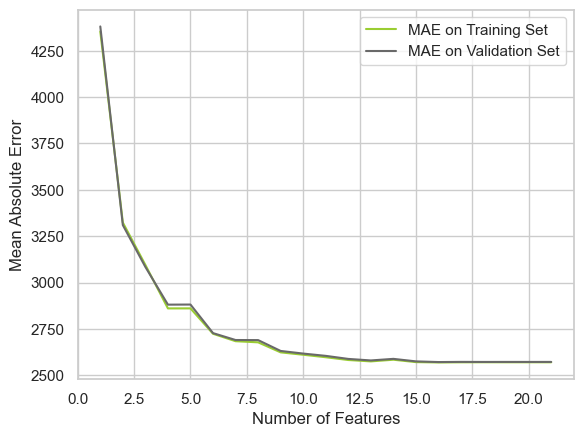

In [ ]:
train_mae_list = wrapped[1]
val_mae_list = wrapped[2]

plt.plot(list(range(1,len(train_mae_list)+1)), train_mae_list, label="MAE on Training Set", color='yellowgreen')
plt.plot(list(range(1,len(val_mae_list)+1)), val_mae_list, label="MAE on Validation Set", color='dimgray')
plt.xlabel("Number of Features")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

<a class="anchor" id="5_3">

## **8.4 Embedded Methods**

[Back to TOP](#TOP)
</a>

Embedded methods perform feature selection as part of the model training process itself. By incorporating regularisation or other model-driven selection criteria, they offer a balance between the efficiency of filter methods and the predictive power of wrapper methods.
Now, we use an embedded method to select features based on their contribution to the model’s optimisation procedure.

<a class="anchor" id="5_3_1">

### **8.4.1 Lasso**

[Back to TOP](#TOP)
</a>

Lasso is a linear regression method that incorporates L1 regularisation to constrain the model’s coefficients. This penalty forces some coefficients to shrink exactly to zero, which means that Lasso performs feature selection as part of the training process. By using this method, we can also define a threshold that helps determine which features should be considered irrelevant when their coefficients are close to zero.

In [ ]:
embedded_cols = lasso_selection(X_train[fm_2], y_train, coef_threshold=100, return_summary=True)

[ 2421.14215256 -1949.61764974   -68.64674363 -3233.81613069
  4149.30838661    16.55463611   -21.7945872    440.10138666
   466.50931093   552.03588204  3223.68756543  -810.03164012
   -22.66272903   160.1838869  -1211.9599698     45.74404117
   455.40814738   179.52127106  2030.73329018  3577.96154912
   857.74252532]
Total features kept: 16
Features selected by Lasso method: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']
Nº Features eliminated: 5


<a class="anchor" id="8_5">

## **8.5 Feature Importance**

[Back to TOP](#TOP)
</a>

In [ ]:
mae_importance = DecisionTreeRegressor(criterion='absolute_error', random_state=42).fit(X_train[fm_2], y_train).feature_importances_
df_fi = pd.DataFrame(mae_importance, index=X_train[fm_2].columns, columns=['MAE Importance'])

<Axes: >

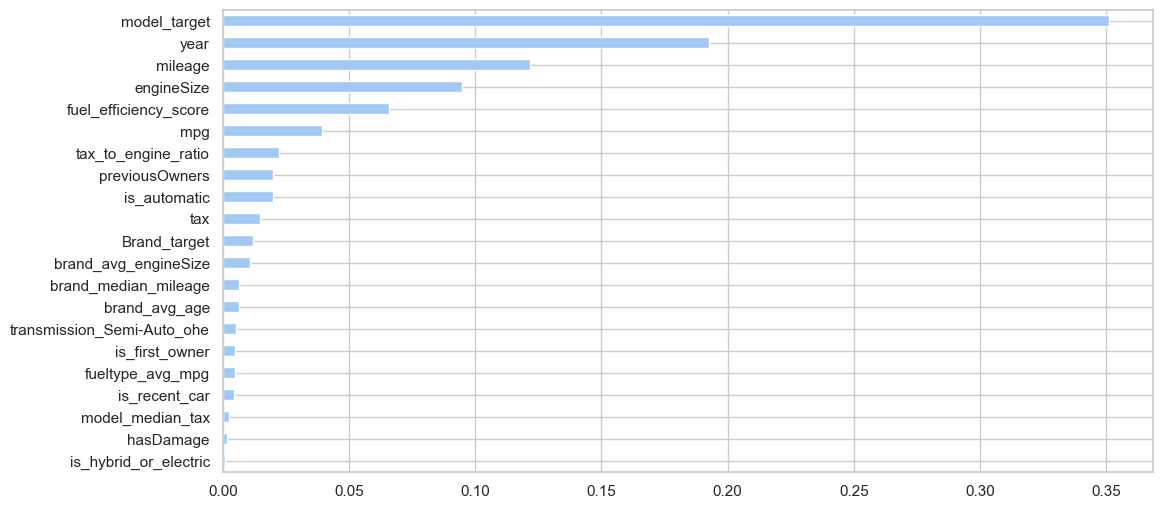

In [ ]:
df_fi = pd.DataFrame(mae_importance, index=X_train[fm_2].columns, columns=['MAE Importance'])
df_fi['MAE Importance'].sort_values().plot(kind='barh', figsize=(12,6))

In [ ]:
feature_importance_cols = (
    df_fi
    .sort_values('MAE Importance', ascending=False)
    .head(6)
    .index
    .tolist()
)
feature_importance_cols

['model_target',
 'year',
 'mileage',
 'engineSize',
 'fuel_efficiency_score',
 'mpg']

<a class="anchor" id="5_4">

## **8.5 Comparison between Models**

[Back to TOP](#TOP)
</a>

As mentioned previously, we will compare the outputs of the different feature selection methods and identify the features that consistently appear as important for our regression model.
The function we defined performs this comparison by selecting the features that are retained by at least a minimum number of methods (n_agreed). For example, if n_agreed = 2, the function returns all features that were selected by two or more of the three methods.

We assign the resulting set of selected features to a variable so that we can later use it to build our final modelling dataset, which will include only these chosen predictors.

In [ ]:
comparison_feature_selection(X_train[fm_2], filter_cols, wrapped_cols, embedded_cols, 
                                                 feature_importance_cols, n_agreed=2, return_summary=True)[1]

Total features before selection: 21
Total features selected by at least 2 methods: 16
Selected features: ['year', 'mileage', 'mpg', 'engineSize', 'is_recent_car', 'is_hybrid_or_electric', 'is_automatic', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_target', 'model_target', 'transmission_Semi-Auto_ohe']


,Feature,Lasso,RFE,Spearman,Feature Importance,Sum
0,year,1,1,1,1,4
1,mileage,1,1,1,1,4
2,tax,0,0,1,0,1
3,mpg,1,1,1,1,4
4,engineSize,1,1,1,1,4
5,previousOwners,0,0,0,0,0
6,hasDamage,0,0,0,0,0
7,is_recent_car,1,1,1,0,3
8,is_hybrid_or_electric,1,1,0,0,2
9,is_automatic,1,1,1,0,3


In [ ]:
all_selected_features = comparison_feature_selection(X_train[fm_2], filter_cols, wrapped_cols, embedded_cols, 
                                                 feature_importance_cols, n_agreed=2)[0]

# Define final datasets with selected features
X_train_final = X_train[all_selected_features]
X_val_final = X_val[all_selected_features]
test_final = test[all_selected_features]

In [ ]:
# We will also create datasets for each feature selection method to compare model performance later 

# Create datasets for each feature selection method
X_train_fm = X_train[filter_cols]
X_val_fm = X_val[filter_cols]

X_train_wm = X_train[wrapped_cols]
X_val_wm = X_val[wrapped_cols]

X_train_emb = X_train[embedded_cols]
X_val_emb = X_val[embedded_cols]

X_train_fi = X_train[feature_importance_cols]
X_val_fi = X_val[feature_importance_cols]

<a class="anchor" id="1">

# **9. Model and Assessment**

[Back to TOP](#TOP)
</a>

Having identified the most significant features through the selection process, we now proceed to train and evaluate the regression models. We start by establishing a baseline and progressively explore more complex models to predict car resale prices effectively. This structured workflow ensures that our models are built upon the most relevant data, optimizing both efficiency and accuracy.

Throughout this section, we continue to utilize the custom functions from our .py files to streamline model implementation and performance assessment.


We begin by concatenating the training and validation datasets and assigning each instance a label that will later be used to create a PredefinedSplit. The purpose of this setup is to ensure that the RandomizedSearchCV uses our custom train–validation split when tuning the hyperparameters of the models we intend to evaluate.

In [ ]:
X_train = X_train_final.copy()
X_val = X_val_final.copy()
test = test_final.copy()

In [ ]:
# Combine train and validation datasets
X_combined = np.concatenate([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

# Create a test fold index (-1 for train, 0 for validation)
test_fold = [-1] * len(X_train) + [0] * len(X_val)

print('Test fold: ', len(test_fold))
print('X_combined: ', len(X_combined))
print('y_combined: ', len(y_combined))

# Define the PredefinedSplit
ps = PredefinedSplit(test_fold=test_fold) # aqui diz que os dados de treino são os que têm label -1 e os de validação são os que têm label 0

Test fold:  75973
X_combined:  75973
y_combined:  75973


<a class="anchor" id="5_1">

## **9.1** Create a Sample to Test Models

[Back to TOP](#TOP)
</a>

In this subsection, we create a sample of our datasets to test the modelling structure and ensure that the code is correctly implemented. Working with a smaller subset speeds up experimentation and allows us to verify the functionality of our models more efficiently. This approach also helps us identify potential issues earlier in the process.

In [ ]:
X_train_s = X_train.sample(1000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]
X_val_s = X_val.sample(500, random_state=42)
y_val_s = y_val.loc[X_val_s.index]

# Recriar combined sample
sample_X_combined = np.concatenate([X_train_s, X_val_s])
sample_y_combined = np.concatenate([y_train_s, y_val_s])

# Novo fold correto!
sample_test_fold = [-1] * len(X_train_s) + [0] * len(X_val_s)

ps_sample = PredefinedSplit(sample_test_fold)

<a class="anchor" id="9_2">

## **9.2** Define the Scores to Evaluate

[Back to TOP](#TOP)
</a>

In this subsection, we define the evaluation metrics that will be used to assess model performance. We create a dictionary containing the selected scoring functions, which can later be passed directly to the RandomizedSearchCV during hyperparameter tuning.

In [ ]:
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}

<a class="anchor" id="9_3">

## **9.3** Test Different Models

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_3_1">

## **9.3.1** LinearRegression

[Back to TOP](#TOP)
</a>

This Algorithm has the following Hyperparameters:
- fit_intercept (default=True): 
- `copy_X (default=True):` If True, X will be copied; else, it may be overwritten.
- `tol (default=1e-06):` The precision of the solution (coef_) is determined by tol
- `n_jobs (default=None):` 
- positive(default=False)

In [54]:
# Linear Regression with Randomized Search CV
model_lr = LinearRegression()

# We test only if the model should calculate the intercept (the base value) or not
param_grid_lr = {
    "fit_intercept": [True, False],
}
# Apply Randomized Search CV
rsCV_lr = apply_randomized_search_cv(
    model_lr, 
    param_grid_lr, 
    iterations=2, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

# Check results
evaluate_model(rsCV_lr)

NameError: name 'scoring' is not defined

## Random Forest

In [201]:
model_rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
}

# Apply Randomized Search CV
rsCV_rf = apply_randomized_search_cv(
    model_rf, 
    param_grid_rf, 
    iterations=1, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

evaluate_model(rsCV_rf)

Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END  mae: (train=-499.007, test=-1316.098) r2: (train=0.991, test=0.947) total time=  26.4s


KeyboardInterrupt: 

In [ ]:
model_rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 8, 10, 12, 15],
    'min_samples_split': [2, 5, 8, 10, 12, 15],
    'max_features': [1, 'sqrt', 'log2'],
    'min_samples_leaf': [1, 5, 8, 10],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.2]
}

# Apply Randomized Search CV
rsCV_rf = apply_randomized_search_cv(
    model_rf, 
    param_grid_rf, 
    iterations=40, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

evaluate_model(rsCV_rf)

Fitting 1 folds for each of 40 candidates, totalling 40 fits
[CV 1/1] END ccp_alpha=0.0, max_depth=None, max_features=log2, min_samples_leaf=5, min_samples_split=12, n_estimators=100; mae: (train=-1173.951, test=-1375.804) r2: (train=0.953, test=0.937) total time=   5.4s
[CV 1/1] END ccp_alpha=0.1, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=15, n_estimators=100; mae: (train=-1014.420, test=-1318.637) r2: (train=0.968, test=0.945) total time=   6.2s
[CV 1/1] END ccp_alpha=0.1, max_depth=15, max_features=1, min_samples_leaf=8, min_samples_split=12, n_estimators=100; mae: (train=-1867.175, test=-1937.282) r2: (train=0.891, test=0.879) total time=   1.7s
[CV 1/1] END ccp_alpha=0.01, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=300; mae: (train=-484.032, test=-1289.026) r2: (train=0.992, test=0.950) total time= 1.8min
[CV 1/1] END ccp_alpha=0.01, max_depth=8, max_features=1, min_samples_leaf=5, min_samples_split=10, n

In [ ]:
best_model_rf = rsCV_rf.best_estimator_
preds_rf = best_model_rf.predict(test.values)

In [ ]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

# Extract carID
car_ids = test.index.values

# Create DataFrame with best model predictions
best_model_df = pd.DataFrame({
    'carID': car_ids,
    'price': preds_rf
})

# Save predictions to CSV
best_model_df.to_csv(f"{selected_dir}/predictions_rf.csv", index=False)

## Bagging

In [202]:
# The parameters here used were obtained from the RandomizedSearchCV above done with RandomForestRegressor
estimator_dt = DecisionTreeRegressor(max_depth=18, min_samples_split=10, min_samples_leaf=5, max_features=None, random_state=42)
model_bag_dt = BaggingRegressor(estimator = estimator_dt, random_state = 42)

param_grid_bag_dt = {
    "n_estimators": [50, 80, 100],       # Number of decision trees
    "max_samples": [0.5, 0.7, 0.8, 0.9],      # Fraction of the dataset to sample
    "max_features": [0.4, 0.5, 0.6],     # Fraction of features to sample (if max_features = 1 then all features are used and the results obtain were terrible)
    "bootstrap": [True, False],          # Sampling with or without replacement
    "bootstrap_features": [False]  # Feature sampling with or without replacement
}

# Apply Randomized Search CV
rsCV_bag_dt = apply_randomized_search_cv(
    model_bag_dt, 
    param_grid_bag_dt, 
    iterations= 72, 
    scoring=scoring, 
    refit='mae', 
    pred_split=ps, 
    X_fit=X_combined, 
    y_fit=y_combined
)

evaluate_model(rsCV_bag_dt)

# IN THIS RESULTS WE NEED TO BE CAREFUL WITH THE POSSIBLE IMPLEMENTATION OF RANDOM FOREST WHEN BOOSTRAP = TRUE & BOOTSTRAP_FEATURES = TRUE


Fitting 1 folds for each of 72 candidates, totalling 72 fits
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=50; mae: (train=-1583.188, test=-1729.577) r2: (train=0.923, test=0.908) total time=   2.2s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=80; mae: (train=-1515.811, test=-1671.944) r2: (train=0.929, test=0.913) total time=   3.7s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.5, n_estimators=100; mae: (train=-1510.058, test=-1665.685) r2: (train=0.929, test=0.914) total time=   4.4s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.7, n_estimators=50; mae: (train=-1534.827, test=-1706.025) r2: (train=0.929, test=0.912) total time=   2.9s
[CV 1/1] END bootstrap=True, bootstrap_features=False, max_features=0.4, max_samples=0.7, n_estimators=80; mae: (train=-1465.979, test=-1648.131) r2: (train=0

In [203]:
best_model_bag_dt = rsCV_bag_dt.best_estimator_
preds_bag_dt = best_model_bag_dt.predict(test.values)

In [204]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

# Extract carID
car_ids = test.index.values

# Create DataFrame with best model predictions
best_model_df = pd.DataFrame({
    'carID': car_ids,
    'price': preds_bag_dt
})

# Save predictions to CSV
best_model_df.to_csv(f"{selected_dir}/predictions_bag_dt.csv", index=False)

<a class="anchor" id="9_3_2">

## **9.3.2** Ridge

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_3_3">

## **9.3.3** Lasso

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_3_3">

## **9.4** Decision Trees 

[Back to TOP](#TOP)
</a>

<a class="anchor" id="9_3_1">

## **9.3.1** KNN

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_1">

### 9.3.1 Define Model and Grid Parameters

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_2">

### 9.3.2 Test KNN using Samples

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_3">

### 9.3.3 Test KNN using the entire Dataset

[Back to TOP](#TOP)
</a>

Analyzing the previous results, we observed that the models using weights='distance' displayed clear signs of overfitting. Based on this, we defined a new parameter grid that excludes this option in order to evaluate whether better and more stable results can be achieved.

In [ ]:
model_KNN = KNeighborsRegressor()
param_grid_knn = {
    "n_neighbors": [10, 20, 30, 40, 50, 80, 100],
    "weights": ["uniform"],
    "p": [1, 2],                                # Manhattan vs Euclidiane
    "leaf_size": [2, 5, 8, 12, 17, 25, 30, 40, 50, 60, 70, 80, 90, 100],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

<a class="anchor" id="9_3_1">

## **9.3.1** Neural Networks

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_5_2">

### 5.5.2 Test Neural Networks using Samples

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_5_3">

### 5.5.3 Test Neural Networks using the entire Dataset

[Back to TOP](#TOP)
</a>

<a class="anchor" id="6">

# **10. Save results to Kaggle**

[Back to TOP](#TOP)
</a>

In [ ]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

In [ ]:
# Extract carID
car_ids = test.index.values

# Create DataFrame with best model predictions
best_model_df = pd.DataFrame({
    'carID': car_ids,
    'price': preds_rf_default
})

# Save predictions to CSV
best_model_df.to_csv(f"{selected_dir}/predictions_rf_default.csv", index=False)